In [ ]:
# 1. Install necessary libraries
!pip install -q torch torchvision transformers datasets pillow

# 2. Check if GPU is active
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Active Device: {device}")
if torch.cuda.is_available():
    print(f"✅ GPU Model: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ WARNING: GPU not detected. Make sure to set Runtime -> Change runtime type -> T4 GPU.")

✅ Active Device: cuda
✅ GPU Model: Tesla T4


⏳ Downloading public Flickr8k dataset (jxie/flickr8k)...


README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…): reconstructing file:   0%|          |  0.00B /  414MB            

data/train-00000-of-00002-2f8f6bfa852eac(…): downloading bytes:           |  0.00B            

data/train-00001-of-00002-2173151d8cd6c7(…): reconstructing file:   0%|          |  0.00B /  414MB            

...

data/test-00000-of-00001-42a2661d12c73e4(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

✅ Successfully loaded 1000 images!

--- SAMPLE DATA INSPECTION ---
Available keys in dataset: dict_keys(['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'])
Image Object: <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x335 at 0x79C2562EFCB0>
Captions:
  [1] The dogs are in the snow in front of a fence .
  [2] The dogs play on the snow .
  [3] Two brown dogs playfully fight in the snow .
  [4] Two brown dogs wrestle in the snow .
  [5] Two dogs playing in the snow .


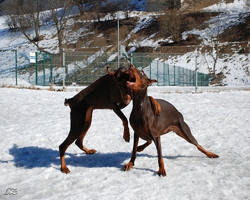

In [ ]:
from datasets import load_dataset
from PIL import Image

print("⏳ Downloading public Flickr8k dataset (jxie/flickr8k)...")

# Load the test split (1,000 images, public & no login required)
dataset = load_dataset("jxie/flickr8k", split="test")

print(f"✅ Successfully loaded {len(dataset)} images!")

# Inspect the first sample
sample = dataset[0]
print("\n--- SAMPLE DATA INSPECTION ---")
print("Available keys in dataset:", sample.keys())
print("Image Object:", sample["image"])

# In jxie/flickr8k, captions are stored as caption_0, caption_1, etc.
print("Captions:")
for i in range(5):
    key = f"caption_{i}"
    if key in sample:
        print(f"  [{i+1}] {sample[key]}")

# Display the image
display(sample["image"].resize((250, 200)))

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import AutoTokenizer

# 1. DEFINE IMAGE AUGMENTATION & NORMALIZATION
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), # Random flip to prevent overfitting
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], # ImageNet channel means
        std=[0.229, 0.224, 0.225]   # ImageNet channel stds
    )
])

# 2. LOAD TOKENIZER
print("Loading DistilBERT Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# 3. CUSTOM PYTORCH DATASET
class CLIPDataset(Dataset):
    def __init__(self, hf_dataset, tokenizer, transforms, max_length=64):
        self.dataset = hf_dataset
        self.tokenizer = tokenizer
        self.transforms = transforms
        self.max_length = max_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        # A. Process Image
        image = item["image"].convert("RGB")
        image_tensor = self.transforms(image)

        # B. Process Text (Pick primary caption: caption_0)
        caption = item.get("caption_0", "A photo")

        # C. Tokenize
        tokenized = self.tokenizer(
            caption,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "image": image_tensor,
            "input_ids": tokenized["input_ids"].squeeze(0),
            "attention_mask": tokenized["attention_mask"].squeeze(0),
            "caption": caption
        }

# 4. CREATE DATALOADER
train_dataset = CLIPDataset(dataset, tokenizer, image_transforms)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)

print(f"✅ Total samples: {len(train_dataset)}")
print(f"✅ Total batches (batch size 32): {len(train_loader)}")

# 5. SANITY CHECK: Pull a single batch to verify shapes
batch = next(iter(train_loader))
print("\n--- BATCH SHAPES CHECK ---")
print("Images tensor shape (should be [32, 3, 224, 224]):", batch["image"].shape)
print("Input IDs shape     (should be [32, 64]):", batch["input_ids"].shape)
print("Attention mask shape(should be [32, 64]):", batch["attention_mask"].shape)
print("Sample caption from batch:", batch["caption"][0])

Loading DistilBERT Tokenizer...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

✅ Total samples: 1000
✅ Total batches (batch size 32): 32

--- BATCH SHAPES CHECK ---
Images tensor shape (should be [32, 3, 224, 224]): torch.Size([32, 3, 224, 224])
Input IDs shape     (should be [32, 64]): torch.Size([32, 64])
Attention mask shape(should be [32, 64]): torch.Size([32, 64])
Sample caption from batch: A pale colored dog runs through a body of water .


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from transformers import AutoModel

# -------------------------------------------------------------
# 1. PROJECTION HEAD
# -------------------------------------------------------------
class ProjectionHead(nn.Module):
    """
    Maps image (512-dim) and text (768-dim) into a shared 256-dim space.
    Uses GELU activation, residual connection, and LayerNorm for stable gradients.
    """
    def __init__(self, embedding_dim, projection_dim=256, dropout=0.1):
        super().__init__()
        self.projection = nn.Linear(embedding_dim, projection_dim)
        self.gelu = nn.GELU()
        self.fc = nn.Linear(projection_dim, projection_dim)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(projection_dim)

    def forward(self, x):
        projected = self.projection(x)
        x = self.gelu(projected)
        x = self.fc(x)
        x = self.dropout(x)
        x = x + projected  # Residual skip connection
        x = self.layer_norm(x)
        return x

# -------------------------------------------------------------
# 2. IMAGE ENCODER (ResNet-18)
# -------------------------------------------------------------
class ImageEncoder(nn.Module):
    def __init__(self, projection_dim=256):
        super().__init__()
        # Load lightweight ResNet-18 with pretrained ImageNet weights
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # Remove the final 1000-class classification head
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.projection_head = ProjectionHead(embedding_dim=512, projection_dim=projection_dim)

    def forward(self, x):
        # Input shape: [batch_size, 3, 224, 224]
        features = self.backbone(x)           # [batch_size, 512, 1, 1]
        features = torch.flatten(features, 1) # [batch_size, 512]
        return self.projection_head(features) # [batch_size, 256]

# -------------------------------------------------------------
# 3. TEXT ENCODER (DistilBERT)
# -------------------------------------------------------------
class TextEncoder(nn.Module):
    def __init__(self, projection_dim=256):
        super().__init__()
        self.transformer = AutoModel.from_pretrained("distilbert-base-uncased")
        self.projection_head = ProjectionHead(embedding_dim=768, projection_dim=projection_dim)

    def forward(self, input_ids, attention_mask):
        # Extract representation from DistilBERT
        output = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        # Grab the [CLS] token at index 0 (captures entire sentence meaning)
        cls_token = output.last_hidden_state[:, 0, :] # [batch_size, 768]
        return self.projection_head(cls_token)        # [batch_size, 256]

# -------------------------------------------------------------
# 4. FULL DUAL-TOWER MODEL (Mini-CLIP)
# -------------------------------------------------------------
class MiniCLIP(nn.Module):
    def __init__(self, projection_dim=256, initial_temperature=0.07):
        super().__init__()
        self.image_encoder = ImageEncoder(projection_dim=projection_dim)
        self.text_encoder = TextEncoder(projection_dim=projection_dim)
        # Learnable log-temperature parameter (log ensures tau > 0 always)
        self.log_temperature = nn.Parameter(torch.tensor(initial_temperature).log())

    def forward(self, images, input_ids, attention_mask):
        # Step A: Extract embeddings
        image_embeds = self.image_encoder(images)
        text_embeds = self.text_encoder(input_ids, attention_mask)

        # Step B: L2 Normalize to the unit hypersphere
        image_embeds = F.normalize(image_embeds, p=2, dim=-1)
        text_embeds = F.normalize(text_embeds, p=2, dim=-1)

        # Step C: Compute similarity matrix (scaled dot product)
        temperature = self.log_temperature.exp()
        # [batch_size, 256] x [256, batch_size] = [batch_size, batch_size]
        logits = torch.matmul(image_embeds, text_embeds.t()) / temperature
        return logits

# -------------------------------------------------------------
# 5. SYMMETRIC INFONCE CONTRASTIVE LOSS
# -------------------------------------------------------------
class ContrastiveLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.cross_entropy = nn.CrossEntropyLoss()

    def forward(self, logits):
        batch_size = logits.size(0)
        # Ground truth labels: diagonal indices [0, 1, 2, ..., batch_size-1]
        labels = torch.arange(batch_size, device=logits.device)

        # Symmetric cross-entropy
        loss_i2t = self.cross_entropy(logits, labels)       # Image to Text
        loss_t2i = self.cross_entropy(logits.t(), labels)   # Text to Image
        return (loss_i2t + loss_t2i) / 2.0

print("✅ Model classes and Loss Function defined successfully!")

✅ Model classes and Loss Function defined successfully!


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from transformers import AutoModel

# -------------------------------------------------------------
# 1. PROJECTION HEAD
# -------------------------------------------------------------
class ProjectionHead(nn.Module):
    def __init__(self, embedding_dim, projection_dim=256, dropout=0.1):
        super().__init__()
        self.projection = nn.Linear(embedding_dim, projection_dim)
        self.gelu = nn.GELU()
        self.fc = nn.Linear(projection_dim, projection_dim)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(projection_dim)

    def forward(self, x):
        projected = self.projection(x)
        x = self.gelu(projected)
        x = self.fc(x)
        x = self.dropout(x)
        x = x + projected  # Residual skip connection
        x = self.layer_norm(x)
        return x

# -------------------------------------------------------------
# 2. IMAGE ENCODER (ResNet-18)
# -------------------------------------------------------------
class ImageEncoder(nn.Module):
    def __init__(self, projection_dim=256):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.projection_head = ProjectionHead(embedding_dim=512, projection_dim=projection_dim)

    def forward(self, x):
        features = self.backbone(x)
        features = torch.flatten(features, 1)
        return self.projection_head(features)

# -------------------------------------------------------------
# 3. TEXT ENCODER (DistilBERT)
# -------------------------------------------------------------
class TextEncoder(nn.Module):
    def __init__(self, projection_dim=256):
        super().__init__()
        self.transformer = AutoModel.from_pretrained("distilbert-base-uncased")
        self.projection_head = ProjectionHead(embedding_dim=768, projection_dim=projection_dim)

    def forward(self, input_ids, attention_mask):
        output = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        cls_token = output.last_hidden_state[:, 0, :]
        return self.projection_head(cls_token)

# -------------------------------------------------------------
# 4. FULL DUAL-TOWER MODEL (Mini-CLIP)
# -------------------------------------------------------------
class MiniCLIP(nn.Module):
    def __init__(self, projection_dim=256, initial_temperature=0.07):
        super().__init__()
        self.image_encoder = ImageEncoder(projection_dim=projection_dim)
        self.text_encoder = TextEncoder(projection_dim=projection_dim)
        self.log_temperature = nn.Parameter(torch.tensor(initial_temperature).log())

    def forward(self, images, input_ids, attention_mask):
        image_embeds = self.image_encoder(images)
        text_embeds = self.text_encoder(input_ids, attention_mask)

        # L2 Normalize
        image_embeds = F.normalize(image_embeds, p=2, dim=-1)
        text_embeds = F.normalize(text_embeds, p=2, dim=-1)

        # Scaled cosine similarity
        temperature = self.log_temperature.exp()
        logits = torch.matmul(image_embeds, text_embeds.t()) / temperature
        return logits

# -------------------------------------------------------------
# 5. SYMMETRIC INFONCE CONTRASTIVE LOSS
# -------------------------------------------------------------
class ContrastiveLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.cross_entropy = nn.CrossEntropyLoss()

    def forward(self, logits):
        batch_size = logits.size(0)
        labels = torch.arange(batch_size, device=logits.device)
        loss_i2t = self.cross_entropy(logits, labels)
        loss_t2i = self.cross_entropy(logits.t(), labels)
        return (loss_i2t + loss_t2i) / 2.0

# -------------------------------------------------------------
# 6. INSTANT VERIFICATION CHECK
# -------------------------------------------------------------
model = MiniCLIP().to(device)
criterion = ContrastiveLoss()

test_images = batch["image"].to(device)
test_ids = batch["input_ids"].to(device)
test_mask = batch["attention_mask"].to(device)

logits = model(test_images, test_ids, test_mask)
loss = criterion(logits)

print("\n--- MODEL VERIFICATION ---")
print("Logits Matrix shape (should be [32, 32]):", logits.shape)
print("Initial Loss value:", round(loss.item(), 4))
print(f"Current Temperature (Tau): {model.log_temperature.exp().item():.4f}")
print("🎉 SUCCESS: Model forward pass and loss calculation working perfectly!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 123MB/s]


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- MODEL VERIFICATION ---
Logits Matrix shape (should be [32, 32]): torch.Size([32, 32])
Initial Loss value: 3.564
Current Temperature (Tau): 0.0700
🎉 SUCCESS: Model forward pass and loss calculation working perfectly!


In [ ]:
import torch
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm

# 1. OPTIMIZER WITH DIFFERENTIAL LEARNING RATES
optimizer_grouped_parameters = [
    # Pretrained backbones: Low learning rate (fine-tuning)
    {"params": model.image_encoder.backbone.parameters(), "lr": 1e-5},
    {"params": model.text_encoder.transformer.parameters(), "lr": 1e-5},
    # New projection heads & temperature: Higher learning rate
    {"params": model.image_encoder.projection_head.parameters(), "lr": 1e-4},
    {"params": model.text_encoder.projection_head.parameters(), "lr": 1e-4},
    {"params": [model.log_temperature], "lr": 1e-3}
]

optimizer = torch.optim.AdamW(optimizer_grouped_parameters, weight_decay=1e-4)

# 2. SCHEDULER & MIXED PRECISION SCALER
num_epochs = 3  # 3 epochs is fast (~3-4 minutes on Colab T4) and effective!
scheduler = CosineAnnealingLR(optimizer, T_max=len(train_loader) * num_epochs, eta_min=1e-6)
scaler = GradScaler()

print(f"🚀 Starting training on {device} for {num_epochs} epochs...")

# 3. TRAINING LOOP
model.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for step, batch in enumerate(progress_bar):
        images = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        optimizer.zero_grad()

        # Forward pass with Automatic Mixed Precision (FP16)
        with autocast():
            logits = model(images, input_ids, attention_mask)
            loss = criterion(logits)

        # Backward pass with scaled gradients
        scaler.scale(loss).backward()

        # Gradient clipping to prevent exploding gradients
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Optimizer & scheduler step
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item()

        # Live loss & temperature display
        if (step + 1) % 5 == 0:
            avg_loss = running_loss / (step + 1)
            tau = model.log_temperature.exp().item()
            progress_bar.set_postfix({"Loss": f"{avg_loss:.4f}", "Tau": f"{tau:.4f}"})

    epoch_loss = running_loss / len(train_loader)
    print(f"✨ Epoch [{epoch+1}/{num_epochs}] Finished | Average Loss: {epoch_loss:.4f}")

# 4. SAVE TRAINED WEIGHTS
torch.save(model.state_dict(), "mini_clip_model.pth")
print("\n💾 Model weights saved successfully to 'mini_clip_model.pth'!")

🚀 Starting training on cuda for 3 epochs...


/tmp/ipykernel_3405/2546608863.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch 1/3:   0%|          | 0/32 [00:00<?, ?it/s]

/tmp/ipykernel_3405/2546608863.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3405/2546608863.py:54: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


✨ Epoch [1/3] Finished | Average Loss: 3.3053


Epoch 2/3:   0%|          | 0/32 [00:00<?, ?it/s]

✨ Epoch [2/3] Finished | Average Loss: 2.5528


Epoch 3/3:   0%|          | 0/32 [00:00<?, ?it/s]

✨ Epoch [3/3] Finished | Average Loss: 2.1831

💾 Model weights saved successfully to 'mini_clip_model.pth'!


In [ ]:
# 1. Install Gradio
!pip install -q gradio

import gradio as gr
import torch
import torch.nn.functional as F

# Ensure model is in eval mode
model.eval()

# -------------------------------------------------------------
# 1. PRECOMPUTE GALLERY EMBEDDINGS (Using image_transforms)
# -------------------------------------------------------------
print("⏳ Precomputing gallery embeddings...")
gallery_images = []
gallery_tensors = []

num_gallery = min(100, len(dataset))
for i in range(num_gallery):
    item = dataset[i]
    gallery_images.append(item["image"])
    # Use image_transforms directly
    img_tensor = image_transforms(item["image"].convert("RGB"))
    gallery_tensors.append(img_tensor)

gallery_tensors = torch.stack(gallery_tensors).to(device)

with torch.no_grad():
    gallery_embeds = model.image_encoder(gallery_tensors)
    # L2 normalize image embeddings
    gallery_embeds = F.normalize(gallery_embeds, p=2, dim=-1)

print(f"✅ Gallery ready! Encoded {len(gallery_images)} images into 256-dim vectors.")

# -------------------------------------------------------------
# 2. GRADIO PREDICTION FUNCTION
# -------------------------------------------------------------
def search_ui(query_text, num_results):
    num_results = int(num_results)

    # Tokenize input text query
    tokens = tokenizer(
        query_text,
        padding="max_length",
        truncation=True,
        max_length=64,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        # Text embedding
        text_emb = model.text_encoder(tokens["input_ids"], tokens["attention_mask"])
        text_emb = F.normalize(text_emb, p=2, dim=-1)

        # Cosine similarity matrix: [1, 256] x [256, 100] = [1, 100]
        similarities = torch.matmul(text_emb, gallery_embeds.t()).squeeze(0)

        # Retrieve top matches
        top_k = torch.topk(similarities, k=num_results)
        top_indices = top_k.indices.cpu().numpy()
        top_scores = top_k.values.cpu().numpy()

    results = []
    for idx, score in zip(top_indices, top_scores):
        results.append((gallery_images[idx], f"Similarity: {score:.3f}"))

    return results

# -------------------------------------------------------------
# 3. CREATE & LAUNCH GRADIO UI
# -------------------------------------------------------------
demo = gr.Interface(
    fn=search_ui,
    inputs=[
        gr.Textbox(label="Enter Search Query", placeholder="e.g., a dog running, a child playing, someone in water..."),
        gr.Slider(minimum=1, maximum=5, value=3, step=1, label="Number of Results")
    ],
    outputs=gr.Gallery(label="Matching Images from Gallery", columns=3, height="auto"),
    title="🖼️ Mini-CLIP: Zero-Shot Multimodal Semantic Search",
    description="Custom PyTorch Dual-Tower Architecture trained with InfoNCE Contrastive Loss on Flickr8k.",
    examples=[
        ["a dog running outdoors", 3],
        ["a child playing", 3],
        ["people standing outside", 3]
    ]
)

# Launch with shareable public link
demo.launch(share=True)

⏳ Precomputing gallery embeddings...
✅ Gallery ready! Encoded 100 images into 256-dim vectors.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e34ab19ea347d63fd4.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
